<a href="https://colab.research.google.com/github/dcangundogan/airplanefailureprediction/blob/main/Can_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ==== Core ====
import os, time
import numpy as np
import pandas as pd

# ==== Plots ====
import matplotlib.pyplot as plt
import seaborn as sns


# ==== ML utils ====
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, f1_score, roc_auc_score,
                             accuracy_score, precision_score, recall_score)

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, History
from tensorflow.keras.metrics import AUC, Precision, Recall
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score


np.random.seed(1)
tf.random.set_seed(1)


In [8]:
SEED=42;
SPLIT=0.2;
BATCH_SIZE=64;
EPOCHS=100;


In [9]:
print(tf.__version__)

2.19.0


In [10]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [11]:
# data path = /content/drive/MyDrive/data
#PREPARE THE DATA

train_FD1 = pd.read_csv("/content/drive/MyDrive/data/train_FD001.csv")
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,NaN,NaN,NaN,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,NaN,NaN,NaN,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,NaN,NaN,NaN,NaN,NaN


In [12]:
#understand and then drop the non-unique and constant columns
np.unique(train_FD1['operational_setting_3'])




array([100.])

In [13]:
np.unique(train_FD1['sensor_measurement_1'])

array([518.67])

In [14]:
#Therefore opsetting3 is constant no need for our data
drop_list=["operational_setting_3",'sensor_measurement_1','sensor_measurement_5','sensor_measurement_6','sensor_measurement_10','sensor_measurement_14','sensor_measurement_16','sensor_measurement_18','sensor_measurement_19','sensor_measurement_22','sensor_measurement_23','sensor_measurement_24','sensor_measurement_25','sensor_measurement_26']
train_FD1.drop(drop_list,axis=1,inplace=True)

In [15]:
type(train_FD1)

pandas.core.frame.DataFrame

In [16]:
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044


In [17]:
rul=pd.DataFrame(train_FD1.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul.columns = ["unit_number",'max']
rul.head()

,unit_number,max
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [18]:
train_FD1 = train_FD1.merge(rul, on=['unit_number'], how='left')
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,max
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,192
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,192
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,192
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,192


In [19]:
train_FD1['RUL'] =train_FD1['max'] - train_FD1['time_in_cycles']
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,max,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,192,187


In [20]:
train_FD1.drop(columns=['max'],axis=1,inplace=True)
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,187


In [21]:
type(train_FD1)

pandas.core.frame.DataFrame

In [22]:
test_FD1=pd.read_csv("/content/drive/MyDrive/data/test_FD001.csv")
test_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,392,2388,100.0,38.86,23.3735,NaN,NaN,NaN,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,393,2388,100.0,39.02,23.3916,NaN,NaN,NaN,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,393,2388,100.0,39.08,23.4166,NaN,NaN,NaN,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,391,2388,100.0,39.00,23.3737,NaN,NaN,NaN,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,390,2388,100.0,38.99,23.4130,NaN,NaN,NaN,NaN,NaN


In [23]:
test_FD1.drop(drop_list,axis=1,inplace=True)
test_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8.4052,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8.3803,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8.4441,393,39.08,23.4166
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8.3917,391,39.00,23.3737
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8.4031,390,38.99,23.4130


In [24]:
fd1_y_true = pd.read_csv('/content/drive/MyDrive/data/RUL_FD001.txt', delim_whitespace=True,names=["RUL"])
fd1_y_true.head()

/tmp/ipython-input-2217873213.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fd1_y_true = pd.read_csv('/content/drive/MyDrive/data/RUL_FD001.txt', delim_whitespace=True,names=["RUL"])


,RUL
0,112
1,98
2,69
3,82
4,91


In [25]:
fd1_y_true['unit_number']=fd1_y_true.index
fd1_y_true.set_index('unit_number',inplace=True)
fd1_y_true.head()

,RUL
unit_number,
0,112
1,98
2,69
3,82
4,91


In [26]:
train_FD1.dtypes

,0
unit_number,int64
time_in_cycles,int64
operational_setting_1,float64
operational_setting_2,float64
sensor_measurement_2,float64
sensor_measurement_3,float64
sensor_measurement_4,float64
sensor_measurement_7,float64
sensor_measurement_8,float64
sensor_measurement_9,float64


In [27]:
type(train_FD1)

pandas.core.frame.DataFrame

In [28]:
#normalizing ther data
#do not normalize the unit_number_time_in_cycles and RUl
feats = train_FD1.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])

In [29]:
scaler = StandardScaler()#z score scaler
train_FD1[feats] = scaler.fit_transform(train_FD1[feats])
test_FD1[feats] = scaler.transform(test_FD1[feats])

In [30]:
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.603816,-0.781710,1.348493,1.194427,191
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.275852,-0.781710,1.016528,1.236922,190
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.649144,-2.073094,0.739891,0.503423,189
3,1,4,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-1.971665,-0.781710,0.352598,0.777792,188
4,1,5,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.339845,-0.136018,0.463253,1.059552,187


In [31]:
threshold=50 #maybe more accurate number i am not sure
train_FD1['failure']=[1 if i<threshold else 0 for i in train_FD1.RUL]
fd1_y_true['failure'] = [1 if i <threshold else 0 for i in fd1_y_true.RUL]


In [32]:
fd1_y_true.head()

,RUL,failure
unit_number,,
0,112,0
1,98,0
2,69,0
3,82,0
4,91,0


In [33]:
test_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21
0,1,1,1.055599,1.015677,0.678077,-0.853550,-1.191480,0.601408,-0.798093,-0.682579,-1.277396,0.415614,-0.919841,-0.985107,-0.781710,0.241943,0.774097
1,1,2,-1.230366,-1.031720,-1.941707,-0.338137,-1.501467,1.674769,-1.220725,-0.490117,-0.154141,1.012195,-0.502695,-1.649034,-0.136018,1.127183,0.941305
2,1,3,0.141213,0.333211,-0.441831,-0.584426,-0.843717,0.838677,-0.657216,-0.375093,-0.154141,0.754581,-0.919841,0.052112,-0.136018,1.459148,1.172256
3,1,4,1.924266,-0.008022,-0.481827,-1.044384,-0.279297,0.793483,-0.938970,-0.903570,-0.977861,-0.045381,-0.641744,-1.345067,-1.427402,1.016528,0.775945
4,1,5,0.644125,-0.008022,-0.341839,-0.543650,-0.779276,0.895170,-1.220725,-0.937081,-0.865536,0.998637,-0.919841,-1.041101,-2.073094,0.961200,1.138999


In [34]:
train_FD1.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL,failure
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.603816,-0.781710,1.348493,1.194427,191,0
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.275852,-0.781710,1.016528,1.236922,190,0
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.649144,-2.073094,0.739891,0.503423,189,0
3,1,4,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-1.971665,-0.781710,0.352598,0.777792,188,0
4,1,5,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.339845,-0.136018,0.463253,1.059552,187,0


In [35]:
train_FD1.shape

(20631, 19)

In [36]:
test_FD1.shape

(13096, 17)

In [37]:

#sliding window technique thats called
#in LSTM it want 3-D numpy input data so convert the train and test data we need to make input like (batch size , timesteps,features)
def convert_3d_numpy_train(df,seq,cols):
  data= df[cols].values
  num_elements=data.shape[0]
  lstm_array=[]
  for start, stop in zip(range(0, num_elements-seq+1), range(seq, num_elements+1)):
    lstm_array.append(data[start:stop,:])
  return np.array(lstm_array)


In [38]:

def convert_3d_numpy_preds(df,seq,label):
  data= df[label].values
  num_elements=data.shape[0]
  return data[seq-1:num_elements+1]


In [39]:
def convert_3d_numpy_test(df,seq,cols,mask):
  df_mask = pd.DataFrame(np.zeros((seq-1,df.shape[1])),columns=df.columns)
  df_mask[:] = mask
  id_df1 = pd.concat([df_mask, df],ignore_index=True)
  data_array = id_df1[cols].values
  num_elements = data_array.shape[0]
  lstm_array=[]
  start = num_elements-seq
  stop = num_elements
  lstm_array.append(data_array[start:stop, :])
  return np.array(lstm_array)

In [40]:
seq_length=50
mask=0 #for zero padding

In [41]:
X_train=np.concatenate(list(list(convert_3d_numpy_train(train_FD1[train_FD1['unit_number']==unit], seq_length, feats)) for unit in train_FD1['unit_number'].unique()))
print(X_train.shape)

(15731, 50, 15)


In [42]:
#generate target of train
y_train = np.concatenate(list(list(convert_3d_numpy_preds(train_FD1[train_FD1['unit_number']==unit], seq_length, "failure")) for unit in train_FD1['unit_number'].unique()))
y_train.shape

(15731,)

In [43]:
X_test=np.concatenate(list(list(convert_3d_numpy_test(test_FD1[test_FD1['unit_number']==unit], seq_length, feats, mask)) for unit in test_FD1['unit_number'].unique()))
print(X_test.shape)

(100, 50, 15)


In [44]:
y_test = fd1_y_true.RUL.values
y_test.shape

(100,)

In [45]:
nb_features = X_train.shape[2]
nb_out = 1

In [46]:
nb_features, nb_out

(15, 1)

In [47]:
class_0 = pd.Series(y_train).value_counts()[0]
class_1 = pd.Series(y_train).value_counts()[1]
total = class_0 + class_1
class_weight = {0: class_1/total, 1: class_0/total}


In [48]:
class_weight

{0: np.float64(0.3178437480134766), 1: np.float64(0.6821562519865234)}

In [49]:
def print_results(y_test, y_pred):
    #f1-score
    f1 = f1_score(y_test, y_pred)
    print("F1 Score: ", f1)
    print(classification_report(y_test, y_pred))
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12,12))
    plt.subplot(221)
    sns.heatmap(conf_matrix, fmt="d", annot=True, cmap='Blues')
    b, t = plt.ylim()
    plt.ylim(b + 0.5, t - 0.5)
    plt.title('Confuion Matrix')
    plt.ylabel('True Values')
    plt.xlabel('Predicted Values')
    #roc_auc_score
    model_roc_auc = roc_auc_score(y_test, y_pred)
    print ("Area under curve : ",model_roc_auc,"\n")
    fpr,tpr,thresholds = roc_curve(y_test, y_pred)
    gmeans = np.sqrt(tpr * (1-fpr))
    ix = np.argmax(gmeans)
    threshold = np.round(thresholds[ix],3)
    plt.subplot(222)
    plt.plot(fpr, tpr, color='darkorange', lw=1, label = "Auc : %.3f" %model_roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best Threshold:' + str(threshold))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")

In [50]:
def train_LSTM_classifier(timesteps, features, batch_size=128, class_weight=None, mask_value=0.0):
    model = Sequential([
        Input(shape=(timesteps, features), name='input'),
        Masking(mask_value=mask_value, name='mask'),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
        LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2, name='lstm_2'),
        Dense(32, activation='relu', name='fc1'),
        Dropout(0.3),
        Dense(1, activation='sigmoid', name='out')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc'), AUC(name='pr_auc', curve='PR'), Precision(), Recall()]
    )
    cbs = [
    ModelCheckpoint('best.h5', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
]
    return model, cbs


In [51]:
timesteps = X_train.shape[1]
features  = X_train.shape[2]

model, cbs = train_LSTM_classifier(timesteps, features, batch_size=128, class_weight=class_weight, mask_value=0.0)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mask (Masking)                  │ (None, 50, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 50, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,657 (244.75 KB)

 Trainable params: 62,657 (244.75 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=128, class_weight=class_weight, callbacks=cbs, shuffle=True)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7977 - auc: 0.9288 - loss: 0.1682 - pr_auc: 0.8763 - precision: 0.6407 - recall: 0.9380
Epoch 1: val_loss improved from inf to 0.19600, saving model to best.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 48s 347ms/step - accuracy: 0.7983 - auc: 0.9291 - loss: 0.1677 - pr_auc: 0.8768 - precision: 0.6416 - recall: 0.9379 - val_accuracy: 0.8980 - val_auc: 0.9814 - val_loss: 0.1960 - val_pr_auc: 0.9636 - val_precision: 0.7555 - val_recall: 0.9511 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9228 - auc: 0.9801 - loss: 0.0782 - pr_auc: 0.9626 - precision: 0.8407 - recall: 0.9428
Epoch 2: val_loss improved from 0.19600 to 0.14489, saving model to best.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 327ms/step - accuracy: 0.9228 - auc: 0.9801 - loss: 0.0782 - pr_auc: 0.9626 - precision: 0.8407 - recall: 0.9428 - val_accuracy: 0.9352 - val_auc: 0.9867 - val_loss: 0.1449 - val_pr_auc: 0.9742 - val_precision: 0.8425 - val_recall: 0.9511 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9303 - auc: 0.9839 - loss: 0.0707 - pr_auc: 0.9690 - precision: 0.8557 - recall: 0.9467
Epoch 3: val_loss improved from 0.14489 to 0.14155, saving model to best.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 322ms/step - accuracy: 0.9304 - auc: 0.9839 - loss: 0.0707 - pr_auc: 0.9690 - precision: 0.8558 - recall: 0.9467 - val_accuracy: 0.9352 - val_auc: 0.9893 - val_loss: 0.1415 - val_pr_auc: 0.9770 - val_precision: 0.8392 - val_recall: 0.9567 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9409 - auc: 0.9877 - loss: 0.0611 - pr_auc: 0.9771 - precision: 0.8757 - recall: 0.9550
Epoch 4: val_loss improved from 0.14155 to 0.13004, saving model to best.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - accuracy: 0.9409 - auc: 0.9877 - loss: 0.0611 - pr_auc: 0.9771 - precision: 0.8758 - recall: 0.9550 - val_accuracy: 0.9457 - val_auc: 0.9886 - val_loss: 0.1300 - val_pr_auc: 0.9752 - val_precision: 0.8849 - val_recall: 0.9311 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9443 - auc: 0.9882 - loss: 0.0590 - pr_auc: 0.9789 - precision: 0.8826 - recall: 0.9570
Epoch 5: val_loss did not improve from 0.13004
99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step - accuracy: 0.9443 - auc: 0.9882 - loss: 0.0590 - pr_auc: 0.9789 - precision: 0.8826 - recall: 0.9570 - val_accuracy: 0.9266 - val_auc: 0.9900 - val_loss: 0.1668 - val_pr_auc: 0.9760 - val_precision: 0.8077 - val_recall: 0.9756 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9442 - auc: 0.9886 - loss: 0.0588 - pr_auc: 0.9781 - precision: 0.8809 - recall: 0.9592
Epoch 6: val_loss did not improve from 0.13004

Epoch 6: 

99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.9478 - auc: 0.9906 - loss: 0.0524 - pr_auc: 0.9813 - precision: 0.8908 - recall: 0.9579 - val_accuracy: 0.9482 - val_auc: 0.9900 - val_loss: 0.1277 - val_pr_auc: 0.9772 - val_precision: 0.8891 - val_recall: 0.9356 - learning_rate: 5.0000e-04
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9515 - auc: 0.9915 - loss: 0.0498 - pr_auc: 0.9841 - precision: 0.8932 - recall: 0.9673
Epoch 8: val_loss did not improve from 0.12772
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 316ms/step - accuracy: 0.9515 - auc: 0.9915 - loss: 0.0497 - pr_auc: 0.9841 - precision: 0.8932 - recall: 0.9673 - val_accuracy: 0.9485 - val_auc: 0.9884 - val_loss: 0.1342 - val_pr_auc: 0.9739 - val_precision: 0.8951 - val_recall: 0.9289 - learning_rate: 5.0000e-04
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9474 - auc: 0.9919 - loss: 0.0498 - pr_auc: 0.9844 - precision: 0.8904 - recall: 0.9570
Epoch 9: val_loss did not improve from 0.12772

E

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step
F1 Score:  0.9523809523809523
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        70
           1       0.91      1.00      0.95        30

    accuracy                           0.97       100
   macro avg       0.95      0.98      0.97       100
weighted avg       0.97      0.97      0.97       100

Area under curve :  0.9785714285714286 



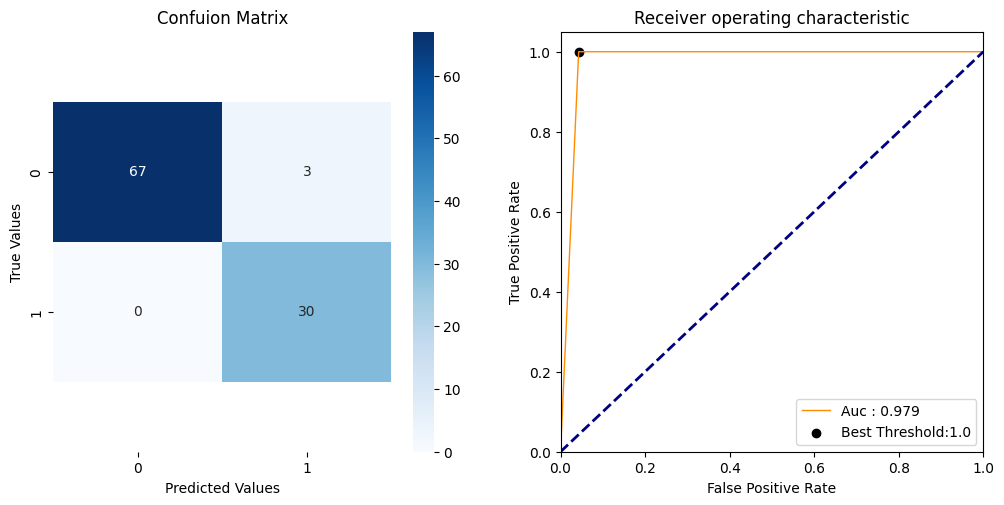

In [53]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print_results(fd1_y_true.failure, y_pred)

### For Train FD002 w/ same processes




In [55]:
data_path = "/content/drive/MyDrive/data"

In [56]:
print("Processing FD002...")
train_FD2 = pd.read_csv(f"{data_path}/train_FD002.csv")

Processing FD002...


In [57]:
train_FD2.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,334,2223,100.00,14.73,8.8071,NaN,NaN,NaN,NaN,NaN
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,330,2212,100.00,10.41,6.2665,NaN,NaN,NaN,NaN,NaN
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,309,1915,84.93,14.08,8.6723,NaN,NaN,NaN,NaN,NaN
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,329,2212,100.00,10.59,6.4701,NaN,NaN,NaN,NaN,NaN
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,309,1915,84.93,14.13,8.5286,NaN,NaN,NaN,NaN,NaN


In [58]:
drop_list_FD2 = ['sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6',
                 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18',
                 'sensor_measurement_19','sensor_measurement_22','sensor_measurement_23','sensor_measurement_24','sensor_measurement_25','sensor_measurement_26']
train_FD2.drop(drop_list_FD2, axis=1, inplace=True)

In [59]:
rul_FD2 = pd.DataFrame(train_FD2.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul_FD2.columns = ["unit_number", 'max']
train_FD2 = train_FD2.merge(rul_FD2, on=['unit_number'], how='left')
train_FD2['RUL'] = train_FD2['max'] - train_FD2['time_in_cycles']
train_FD2.drop(columns=['max'], axis=1, inplace=True)

In [60]:
test_FD2 = pd.read_csv(f"{data_path}/test_FD002.csv")
test_FD2.drop(drop_list_FD2, axis=1, inplace=True)

In [61]:
fd2_y_true = pd.read_csv(f'{data_path}/RUL_FD002.txt', delim_whitespace=True, names=["RUL"])
fd2_y_true['unit_number'] = fd2_y_true.index + 1
fd2_y_true.set_index('unit_number', inplace=True)

/tmp/ipython-input-3549020561.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fd2_y_true = pd.read_csv(f'{data_path}/RUL_FD002.txt', delim_whitespace=True, names=["RUL"])


In [62]:
feats_FD2 = train_FD2.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])
scaler_FD2 = StandardScaler()
train_FD2[feats_FD2] = scaler_FD2.fit_transform(train_FD2[feats_FD2])
test_FD2[feats_FD2] = scaler_FD2.transform(test_FD2[feats_FD2])

In [66]:
np.mean(rul_FD2['max'])

np.float64(206.76538461538462)

In [67]:
train_FD2['failure'] = [1 if i < threshold else 0 for i in train_FD2.RUL]
fd2_y_true['failure'] = [1 if i < threshold else 0 for i in fd2_y_true.RUL]

In [68]:
print(f"FD002 - Train shape: {train_FD2.shape}, Test shape: {test_FD2.shape}")

FD002 - Train shape: (53759, 21), Test shape: (33991, 19)


In [69]:
# Prepare training data
X_train_FD2 = np.concatenate(list(list(convert_3d_numpy_train(train_FD2[train_FD2['unit_number']==unit], seq_length, feats_FD2)) for unit in train_FD2['unit_number'].unique()))
print(f"X_train_FD2 shape: {X_train_FD2.shape}")

X_train_FD2 shape: (41019, 50, 17)


In [70]:
y_train_FD2 = np.concatenate(list(list(convert_3d_numpy_preds(train_FD2[train_FD2['unit_number']==unit], seq_length, "failure")) for unit in train_FD2['unit_number'].unique()))
print(f"y_train_FD2 shape: {y_train_FD2.shape}")


y_train_FD2 shape: (41019,)


In [71]:
X_test_FD2 = np.concatenate(list(list(convert_3d_numpy_test(test_FD2[test_FD2['unit_number']==unit], seq_length, feats_FD2, mask)) for unit in test_FD2['unit_number'].unique()))
print(f"X_test_FD2 shape: {X_test_FD2.shape}")

X_test_FD2 shape: (259, 50, 17)


In [72]:
y_test_FD2 = fd2_y_true.RUL.values
print(f"y_test_FD2 shape: {y_test_FD2.shape}")

y_test_FD2 shape: (259,)


In [73]:
class_0_FD2 = pd.Series(y_train_FD2).value_counts()[0]
class_1_FD2 = pd.Series(y_train_FD2).value_counts()[1]
total_FD2 = class_0_FD2 + class_1_FD2
class_weight_FD2 = {0: class_1_FD2/total_FD2, 1: class_0_FD2/total_FD2}
print(f"Class weights FD2: {class_weight_FD2}")

Class weights FD2: {0: np.float64(0.3169263024452083), 1: np.float64(0.6830736975547916)}


In [74]:
timesteps_FD2 = X_train_FD2.shape[1]
features_FD2 = X_train_FD2.shape[2]

In [75]:
model_FD2, cbs_FD2 = train_LSTM_classifier(timesteps_FD2, features_FD2, batch_size=128, class_weight=class_weight_FD2, mask_value=0.0)
model_FD2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mask (Masking)                  │ (None, 50, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 50, 128)        │        41,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,681 (248.75 KB)

 Trainable params: 63,681 (248.75 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history_FD2 = model_FD2.fit(X_train_FD2, y_train_FD2, validation_split=0.2, epochs=50, batch_size=128, class_weight=class_weight_FD2, callbacks=cbs_FD2, shuffle=True)


Epoch 1/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7205 - auc: 0.7697 - loss: 0.2433 - pr_auc: 0.6287 - precision_1: 0.5490 - recall_1: 0.6468
Epoch 1: val_loss improved from inf to 0.34398, saving model to best.h5


257/257 ━━━━━━━━━━━━━━━━━━━━ 94s 326ms/step - accuracy: 0.7207 - auc: 0.7700 - loss: 0.2432 - pr_auc: 0.6291 - precision_1: 0.5493 - recall_1: 0.6472 - val_accuracy: 0.8599 - val_auc: 0.9361 - val_loss: 0.3440 - val_pr_auc: 0.8960 - val_precision_1: 0.7543 - val_recall_1: 0.8400 - learning_rate: 0.0010
Epoch 2/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8201 - auc: 0.8948 - loss: 0.1767 - pr_auc: 0.8265 - precision_1: 0.6853 - recall_1: 0.7974
Epoch 2: val_loss improved from 0.34398 to 0.32409, saving model to best.h5


257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8201 - auc: 0.8948 - loss: 0.1767 - pr_auc: 0.8265 - precision_1: 0.6853 - recall_1: 0.7974 - val_accuracy: 0.8620 - val_auc: 0.9443 - val_loss: 0.3241 - val_pr_auc: 0.9086 - val_precision_1: 0.7455 - val_recall_1: 0.8698 - learning_rate: 0.0010
Epoch 3/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8399 - auc: 0.9136 - loss: 0.1610 - pr_auc: 0.8535 - precision_1: 0.7135 - recall_1: 0.8249
Epoch 3: val_loss improved from 0.32409 to 0.29512, saving model to best.h5


257/257 ━━━━━━━━━━━━━━━━━━━━ 83s 321ms/step - accuracy: 0.8399 - auc: 0.9136 - loss: 0.1610 - pr_auc: 0.8535 - precision_1: 0.7135 - recall_1: 0.8250 - val_accuracy: 0.8734 - val_auc: 0.9527 - val_loss: 0.2951 - val_pr_auc: 0.9229 - val_precision_1: 0.7550 - val_recall_1: 0.9000 - learning_rate: 0.0010
Epoch 4/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8494 - auc: 0.9247 - loss: 0.1507 - pr_auc: 0.8735 - precision_1: 0.7274 - recall_1: 0.8384
Epoch 4: val_loss improved from 0.29512 to 0.27132, saving model to best.h5


257/257 ━━━━━━━━━━━━━━━━━━━━ 85s 330ms/step - accuracy: 0.8494 - auc: 0.9247 - loss: 0.1507 - pr_auc: 0.8735 - precision_1: 0.7274 - recall_1: 0.8384 - val_accuracy: 0.8894 - val_auc: 0.9523 - val_loss: 0.2713 - val_pr_auc: 0.9227 - val_precision_1: 0.8111 - val_recall_1: 0.8574 - learning_rate: 0.0010
Epoch 5/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8556 - auc: 0.9316 - loss: 0.1436 - pr_auc: 0.8862 - precision_1: 0.7376 - recall_1: 0.8441
Epoch 5: val_loss did not improve from 0.27132
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8556 - auc: 0.9316 - loss: 0.1436 - pr_auc: 0.8862 - precision_1: 0.7376 - recall_1: 0.8441 - val_accuracy: 0.8748 - val_auc: 0.9535 - val_loss: 0.2925 - val_pr_auc: 0.9226 - val_precision_1: 0.7663 - val_recall_1: 0.8811 - learning_rate: 0.0010
Epoch 6/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8634 - auc: 0.9376 - loss: 0.1375 - pr_auc: 0.8941 - precision_1: 0.7487 - recall_1: 0.8559
Epoch 6: val_loss did not

257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8709 - auc: 0.9450 - loss: 0.1293 - pr_auc: 0.9073 - precision_1: 0.7623 - recall_1: 0.8610 - val_accuracy: 0.8801 - val_auc: 0.9570 - val_loss: 0.2695 - val_pr_auc: 0.9294 - val_precision_1: 0.7788 - val_recall_1: 0.8781 - learning_rate: 5.0000e-04
Epoch 8/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8787 - auc: 0.9487 - loss: 0.1250 - pr_auc: 0.9116 - precision_1: 0.7761 - recall_1: 0.8672
Epoch 8: val_loss did not improve from 0.26947
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 319ms/step - accuracy: 0.8787 - auc: 0.9487 - loss: 0.1250 - pr_auc: 0.9116 - precision_1: 0.7761 - recall_1: 0.8673 - val_accuracy: 0.8748 - val_auc: 0.9567 - val_loss: 0.2794 - val_pr_auc: 0.9284 - val_precision_1: 0.7639 - val_recall_1: 0.8864 - learning_rate: 5.0000e-04
Epoch 9/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8836 - auc: 0.9532 - loss: 0.1195 - pr_auc: 0.9195 - precision_1: 0.7825 - recall_1: 0.8757
Epoch 9: val_loss

257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8836 - auc: 0.9532 - loss: 0.1195 - pr_auc: 0.9195 - precision_1: 0.7825 - recall_1: 0.8757 - val_accuracy: 0.8880 - val_auc: 0.9577 - val_loss: 0.2646 - val_pr_auc: 0.9292 - val_precision_1: 0.7986 - val_recall_1: 0.8736 - learning_rate: 5.0000e-04
Epoch 10/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8838 - auc: 0.9539 - loss: 0.1184 - pr_auc: 0.9200 - precision_1: 0.7824 - recall_1: 0.8767
Epoch 10: val_loss did not improve from 0.26457
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8838 - auc: 0.9539 - loss: 0.1184 - pr_auc: 0.9200 - precision_1: 0.7824 - recall_1: 0.8768 - val_accuracy: 0.8835 - val_auc: 0.9565 - val_loss: 0.2723 - val_pr_auc: 0.9263 - val_precision_1: 0.7835 - val_recall_1: 0.8834 - learning_rate: 5.0000e-04
Epoch 11/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8898 - auc: 0.9571 - loss: 0.1144 - pr_auc: 0.9259 - precision_1: 0.7954 - recall_1: 0.8776
Epoch 11: val_

257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 319ms/step - accuracy: 0.8898 - auc: 0.9571 - loss: 0.1144 - pr_auc: 0.9259 - precision_1: 0.7954 - recall_1: 0.8776 - val_accuracy: 0.8881 - val_auc: 0.9569 - val_loss: 0.2604 - val_pr_auc: 0.9267 - val_precision_1: 0.8067 - val_recall_1: 0.8596 - learning_rate: 5.0000e-04
Epoch 12/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8963 - auc: 0.9601 - loss: 0.1105 - pr_auc: 0.9282 - precision_1: 0.8036 - recall_1: 0.8895
Epoch 12: val_loss did not improve from 0.26041
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - accuracy: 0.8963 - auc: 0.9601 - loss: 0.1105 - pr_auc: 0.9282 - precision_1: 0.8036 - recall_1: 0.8895 - val_accuracy: 0.8841 - val_auc: 0.9561 - val_loss: 0.2661 - val_pr_auc: 0.9252 - val_precision_1: 0.7928 - val_recall_1: 0.8679 - learning_rate: 5.0000e-04
Epoch 13/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8983 - auc: 0.9624 - loss: 0.1071 - pr_auc: 0.9345 - precision_1: 0.8092 - recall_1: 0.8882
Epoch 13: val_

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step

=== FD002 Results ===
F1 Score:  0.8556149732620321
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       172
           1       0.80      0.92      0.86        87

    accuracy                           0.90       259
   macro avg       0.88      0.90      0.89       259
weighted avg       0.90      0.90      0.90       259

Area under curve :  0.9016305800588078 



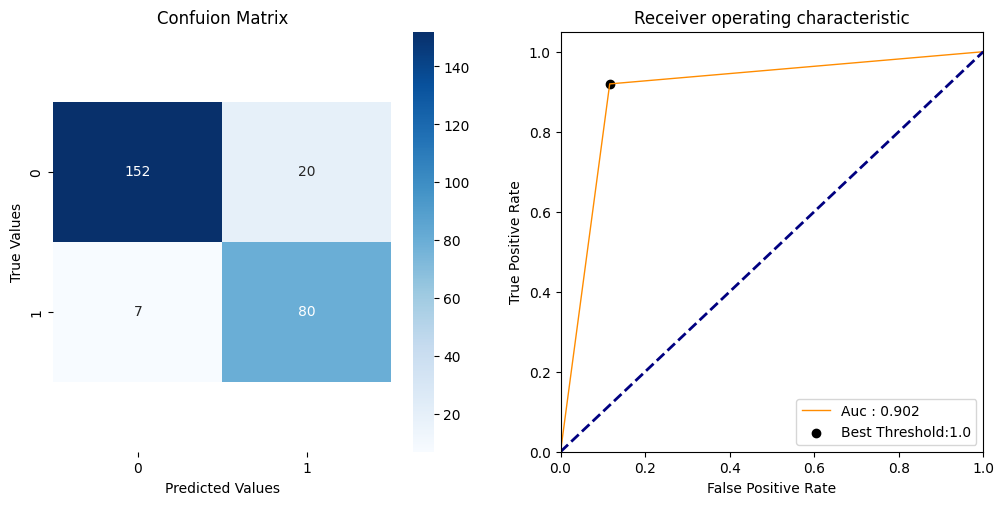

In [77]:
# Predictions and evaluation
y_pred_FD2 = (model_FD2.predict(X_test_FD2) > 0.5).astype("int32")
print("\n=== FD002 Results ===")
print_results(fd2_y_true.failure, y_pred_FD2)

### FD003

In [78]:
print("\nProcessing FD003...")
train_FD3 = pd.read_csv(f"{data_path}/train_FD003.csv")


Processing FD003...


In [79]:
train_FD3.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,391,2388,100.0,39.11,23.3537,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,392,2388,100.0,38.99,23.4491,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,391,2388,100.0,38.85,23.3669,NaN,NaN,NaN,NaN,NaN
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,392,2388,100.0,38.96,23.2951,NaN,NaN,NaN,NaN,NaN
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,392,2388,100.0,39.14,23.4583,NaN,NaN,NaN,NaN,NaN


In [80]:
drop_list_FD3 = ['operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_5',
                 'sensor_measurement_6', 'sensor_measurement_10', 'sensor_measurement_14',
                 'sensor_measurement_16', 'sensor_measurement_18', 'sensor_measurement_19',
                 'sensor_measurement_22', 'sensor_measurement_23', 'sensor_measurement_24',
                 'sensor_measurement_25', 'sensor_measurement_26']
train_FD3.drop(drop_list_FD3, axis=1, inplace=True)

In [81]:
rul_FD3 = pd.DataFrame(train_FD3.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul_FD3.columns = ["unit_number", 'max']
train_FD3 = train_FD3.merge(rul_FD3, on=['unit_number'], how='left')
train_FD3['RUL'] = train_FD3['max'] - train_FD3['time_in_cycles']
train_FD3.drop(columns=['max'], axis=1, inplace=True)

In [82]:
test_FD3 = pd.read_csv(f"{data_path}/test_FD003.csv")
test_FD3.drop(drop_list_FD3, axis=1, inplace=True)

In [83]:
fd3_y_true = pd.read_csv(f'{data_path}/RUL_FD003.txt', delim_whitespace=True, names=["RUL"])
fd3_y_true['unit_number'] = fd3_y_true.index + 1
fd3_y_true.set_index('unit_number', inplace=True)

/tmp/ipython-input-1066941363.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fd3_y_true = pd.read_csv(f'{data_path}/RUL_FD003.txt', delim_whitespace=True, names=["RUL"])


In [84]:
feats_FD3 = train_FD3.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])
scaler_FD3 = StandardScaler()
train_FD3[feats_FD3] = scaler_FD3.fit_transform(train_FD3[feats_FD3])
test_FD3[feats_FD3] = scaler_FD3.transform(test_FD3[feats_FD3])

In [85]:
train_FD3['failure'] = [1 if i < threshold else 0 for i in train_FD3.RUL]
fd3_y_true['failure'] = [1 if i < threshold else 0 for i in fd3_y_true.RUL]

In [86]:
print(f"FD003 - Train shape: {train_FD3.shape}, Test shape: {test_FD3.shape}")

FD003 - Train shape: (24720, 19), Test shape: (16596, 17)


In [87]:
X_train_FD3 = np.concatenate(list(list(convert_3d_numpy_train(train_FD3[train_FD3['unit_number']==unit], seq_length, feats_FD3)) for unit in train_FD3['unit_number'].unique()))
print(f"X_train_FD3 shape: {X_train_FD3.shape}")

X_train_FD3 shape: (19820, 50, 15)


In [88]:
X_train_FD3 = np.concatenate(list(list(convert_3d_numpy_train(train_FD3[train_FD3['unit_number']==unit], seq_length, feats_FD3)) for unit in train_FD3['unit_number'].unique()))
print(f"X_train_FD3 shape: {X_train_FD3.shape}")

X_train_FD3 shape: (19820, 50, 15)


In [89]:
y_train_FD3 = np.concatenate(list(list(convert_3d_numpy_preds(train_FD3[train_FD3['unit_number']==unit], seq_length, "failure")) for unit in train_FD3['unit_number'].unique()))
print(f"y_train_FD3 shape: {y_train_FD3.shape}")

y_train_FD3 shape: (19820,)


In [90]:
X_test_FD3 = np.concatenate(list(list(convert_3d_numpy_test(test_FD3[test_FD3['unit_number']==unit], seq_length, feats_FD3, mask)) for unit in test_FD3['unit_number'].unique()))
print(f"X_test_FD3 shape: {X_test_FD3.shape}")

X_test_FD3 shape: (100, 50, 15)


In [91]:
y_test_FD3 = fd3_y_true.RUL.values
print(f"y_test_FD3 shape: {y_test_FD3.shape}")

y_test_FD3 shape: (100,)


In [92]:
class_0_FD3 = pd.Series(y_train_FD3).value_counts()[0]
class_1_FD3 = pd.Series(y_train_FD3).value_counts()[1]
total_FD3 = class_0_FD3 + class_1_FD3
class_weight_FD3 = {0: class_1_FD3/total_FD3, 1: class_0_FD3/total_FD3}
print(f"Class weights FD3: {class_weight_FD3}")

Class weights FD3: {0: np.float64(0.2522704339051463), 1: np.float64(0.7477295660948536)}


In [93]:
# Build and train model
timesteps_FD3 = X_train_FD3.shape[1]
features_FD3 = X_train_FD3.shape[2]

In [94]:
model_FD3, cbs_FD3 = train_LSTM_classifier(timesteps_FD3, features_FD3, batch_size=128, class_weight=class_weight_FD3, mask_value=0.0)
model_FD3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mask (Masking)                  │ (None, 50, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 50, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,657 (244.75 KB)

 Trainable params: 62,657 (244.75 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
history_FD3 = model_FD3.fit(X_train_FD3, y_train_FD3, validation_split=0.2, epochs=50, batch_size=128, class_weight=class_weight_FD3, callbacks=cbs_FD3, shuffle=True)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7989 - auc: 0.9056 - loss: 0.1501 - pr_auc: 0.7895 - precision_2: 0.5748 - recall_2: 0.9081
Epoch 1: val_loss improved from inf to 0.25023, saving model to best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 51s 335ms/step - accuracy: 0.7995 - auc: 0.9060 - loss: 0.1497 - pr_auc: 0.7902 - precision_2: 0.5756 - recall_2: 0.9083 - val_accuracy: 0.8948 - val_auc: 0.9776 - val_loss: 0.2502 - val_pr_auc: 0.9447 - val_precision_2: 0.7206 - val_recall_2: 0.9541 - learning_rate: 0.0010
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9088 - auc: 0.9702 - loss: 0.0829 - pr_auc: 0.9249 - precision_2: 0.7624 - recall_2: 0.9182
Epoch 2: val_loss improved from 0.25023 to 0.20256, saving model to best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 323ms/step - accuracy: 0.9089 - auc: 0.9702 - loss: 0.0828 - pr_auc: 0.9250 - precision_2: 0.7626 - recall_2: 0.9183 - val_accuracy: 0.9263 - val_auc: 0.9793 - val_loss: 0.2026 - val_pr_auc: 0.9476 - val_precision_2: 0.8116 - val_recall_2: 0.9232 - learning_rate: 0.0010
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9211 - auc: 0.9775 - loss: 0.0714 - pr_auc: 0.9386 - precision_2: 0.7894 - recall_2: 0.9284
Epoch 3: val_loss improved from 0.20256 to 0.15025, saving model to best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 321ms/step - accuracy: 0.9211 - auc: 0.9775 - loss: 0.0714 - pr_auc: 0.9387 - precision_2: 0.7896 - recall_2: 0.9285 - val_accuracy: 0.9374 - val_auc: 0.9875 - val_loss: 0.1502 - val_pr_auc: 0.9650 - val_precision_2: 0.8229 - val_recall_2: 0.9591 - learning_rate: 0.0010
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9297 - auc: 0.9837 - loss: 0.0602 - pr_auc: 0.9540 - precision_2: 0.8043 - recall_2: 0.9464
Epoch 4: val_loss improved from 0.15025 to 0.13750, saving model to best.h5


124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 322ms/step - accuracy: 0.9297 - auc: 0.9837 - loss: 0.0602 - pr_auc: 0.9541 - precision_2: 0.8044 - recall_2: 0.9464 - val_accuracy: 0.9440 - val_auc: 0.9891 - val_loss: 0.1375 - val_pr_auc: 0.9669 - val_precision_2: 0.8465 - val_recall_2: 0.9511 - learning_rate: 0.0010
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9339 - auc: 0.9859 - loss: 0.0552 - pr_auc: 0.9589 - precision_2: 0.8147 - recall_2: 0.9487
Epoch 5: val_loss did not improve from 0.13750
124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.9339 - auc: 0.9859 - loss: 0.0552 - pr_auc: 0.9589 - precision_2: 0.8148 - recall_2: 0.9487 - val_accuracy: 0.9337 - val_auc: 0.9895 - val_loss: 0.1559 - val_pr_auc: 0.9668 - val_precision_2: 0.8033 - val_recall_2: 0.9771 - learning_rate: 0.0010
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9413 - auc: 0.9892 - loss: 0.0494 - pr_auc: 0.9687 - precision_2: 0.8306 - recall_2: 0.9587
Epoch 6: val_loss did not

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step

=== FD003 Results ===
F1 Score:  0.8787878787878788
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        71
           1       0.78      1.00      0.88        29

    accuracy                           0.92       100
   macro avg       0.89      0.94      0.91       100
weighted avg       0.94      0.92      0.92       100

Area under curve :  0.943661971830986 



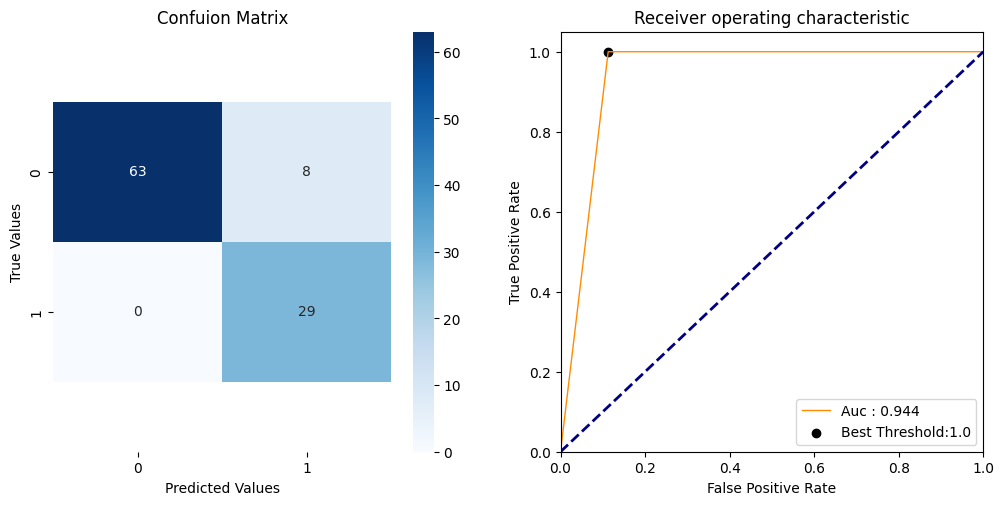

In [96]:
# Predictions and evaluation
y_pred_FD3 = (model_FD3.predict(X_test_FD3) > 0.5).astype("int32")
print("\n=== FD003 Results ===")
print_results(fd3_y_true.failure, y_pred_FD3)

### FD004

In [97]:
print("\nProcessing FD004...")
train_FD4 = pd.read_csv(f"{data_path}/train_FD004.csv")


Processing FD004...


In [116]:
train_FD4.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,...,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL,failure
0,1,1,1.218156,0.864668,0.418783,-0.796416,-0.701412,-0.745729,-0.993802,-0.115765,...,-0.365205,-0.989007,0.417814,0.081921,0.063831,-0.638665,-1.030999,-1.031756,320,0
1,1,2,-0.270478,0.414718,0.418783,0.713666,0.562449,0.298212,0.332051,0.653429,...,0.328498,0.331131,0.415786,-0.253086,-0.125677,0.476120,0.352814,0.358264,319,0
2,1,3,1.218082,0.867565,0.418783,-0.815965,-0.704332,-0.711202,-0.988219,-0.115352,...,-0.374454,-0.990162,0.417658,-0.013912,0.153387,-0.674626,-1.045089,-1.022649,318,0
3,1,4,1.217824,0.864668,0.418783,-0.822660,-0.722040,-0.702990,-0.989581,-0.115627,...,-0.368288,-0.988862,0.418048,0.096162,0.068362,-0.710586,-1.039051,-1.023269,317,0
4,1,5,0.068094,0.158844,-2.387873,-1.160079,-1.532181,-1.410627,-0.738762,-2.156673,...,-1.971512,-0.741097,-2.389666,-2.358027,2.066982,-1.537685,-0.687814,-0.644612,316,0


In [98]:
drop_list_FD4 = ['sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6',
                 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18',
                 'sensor_measurement_19','sensor_measurement_22','sensor_measurement_23','sensor_measurement_24','sensor_measurement_25','sensor_measurement_26']
train_FD4.drop(drop_list_FD4, axis=1, inplace=True)

In [99]:
rul_FD4 = pd.DataFrame(train_FD4.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul_FD4.columns = ["unit_number", 'max']
train_FD4 = train_FD4.merge(rul_FD4, on=['unit_number'], how='left')
train_FD4['RUL'] = train_FD4['max'] - train_FD4['time_in_cycles']
train_FD4.drop(columns=['max'], axis=1, inplace=True)

In [100]:
test_FD4 = pd.read_csv(f"{data_path}/test_FD004.csv")
test_FD4.drop(drop_list_FD4, axis=1, inplace=True)


In [101]:
fd4_y_true = pd.read_csv(f'{data_path}/RUL_FD004.txt', delim_whitespace=True, names=["RUL"])
fd4_y_true['unit_number'] = fd4_y_true.index + 1
fd4_y_true.set_index('unit_number', inplace=True)

/tmp/ipython-input-3552829310.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fd4_y_true = pd.read_csv(f'{data_path}/RUL_FD004.txt', delim_whitespace=True, names=["RUL"])


In [102]:
feats_FD4 = train_FD4.columns.drop(['unit_number', 'time_in_cycles', 'RUL'])
scaler_FD4 = StandardScaler()
train_FD4[feats_FD4] = scaler_FD4.fit_transform(train_FD4[feats_FD4])
test_FD4[feats_FD4] = scaler_FD4.transform(test_FD4[feats_FD4])


In [103]:
train_FD4['failure'] = [1 if i < threshold else 0 for i in train_FD4.RUL]
fd4_y_true['failure'] = [1 if i < threshold else 0 for i in fd4_y_true.RUL]

In [104]:
print(f"FD004 - Train shape: {train_FD4.shape}, Test shape: {test_FD4.shape}")

FD004 - Train shape: (61249, 21), Test shape: (41214, 19)


In [105]:
X_train_FD4 = np.concatenate(list(list(convert_3d_numpy_train(train_FD4[train_FD4['unit_number']==unit], seq_length, feats_FD4)) for unit in train_FD4['unit_number'].unique()))
print(f"X_train_FD4 shape: {X_train_FD4.shape}")


X_train_FD4 shape: (49048, 50, 17)


In [106]:
y_train_FD4 = np.concatenate(list(list(convert_3d_numpy_preds(train_FD4[train_FD4['unit_number']==unit], seq_length, "failure")) for unit in train_FD4['unit_number'].unique()))
print(f"y_train_FD4 shape: {y_train_FD4.shape}")

y_train_FD4 shape: (49048,)


In [107]:
X_test_FD4 = np.concatenate(list(list(convert_3d_numpy_test(test_FD4[test_FD4['unit_number']==unit], seq_length, feats_FD4, mask)) for unit in test_FD4['unit_number'].unique()))
print(f"X_test_FD4 shape: {X_test_FD4.shape}")

X_test_FD4 shape: (248, 50, 17)


In [108]:
y_test_FD4 = fd4_y_true.RUL.values
print(f"y_test_FD4 shape: {y_test_FD4.shape}")

y_test_FD4 shape: (248,)


In [109]:
class_0_FD4 = pd.Series(y_train_FD4).value_counts()[0]
class_1_FD4 = pd.Series(y_train_FD4).value_counts()[1]
total_FD4 = class_0_FD4 + class_1_FD4
class_weight_FD4 = {0: class_1_FD4/total_FD4, 1: class_0_FD4/total_FD4}
print(f"Class weights FD4: {class_weight_FD4}")

Class weights FD4: {0: np.float64(0.2538329799380199), 1: np.float64(0.7461670200619801)}


In [110]:
timesteps_FD4 = X_train_FD4.shape[1]
features_FD4 = X_train_FD4.shape[2]

In [111]:
model_FD4, cbs_FD4 = train_LSTM_classifier(timesteps_FD4, features_FD4, batch_size=128, class_weight=class_weight_FD4, mask_value=0.0)
model_FD4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mask (Masking)                  │ (None, 50, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 50, 128)        │        41,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,681 (248.75 KB)

 Trainable params: 63,681 (248.75 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
history_FD4 = model_FD4.fit(X_train_FD4, y_train_FD4, validation_split=0.2, epochs=50, batch_size=128, class_weight=class_weight_FD4, callbacks=cbs_FD4, shuffle=True)


Epoch 1/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7067 - auc: 0.7977 - loss: 0.1994 - pr_auc: 0.6176 - precision_3: 0.4667 - recall_3: 0.7503
Epoch 1: val_loss improved from inf to 0.28213, saving model to best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 111s 328ms/step - accuracy: 0.7069 - auc: 0.7979 - loss: 0.1994 - pr_auc: 0.6180 - precision_3: 0.4669 - recall_3: 0.7504 - val_accuracy: 0.8844 - val_auc: 0.9457 - val_loss: 0.2821 - val_pr_auc: 0.8825 - val_precision_3: 0.7609 - val_recall_3: 0.8098 - learning_rate: 0.0010
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8216 - auc: 0.8989 - loss: 0.1521 - pr_auc: 0.7746 - precision_3: 0.6066 - recall_3: 0.8227
Epoch 2: val_loss did not improve from 0.28213
307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.8216 - auc: 0.8989 - loss: 0.1521 - pr_auc: 0.7746 - precision_3: 0.6066 - recall_3: 0.8227 - val_accuracy: 0.8803 - val_auc: 0.9477 - val_loss: 0.2848 - val_pr_auc: 0.8910 - val_precision_3: 0.7278 - val_recall_3: 0.8620 - learning_rate: 0.0010
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8447 - auc: 0.9203 - loss: 0.1357 - pr_auc: 0.8166 - precision_3: 0.6454 - recall_3: 0.8462
Epoch 3: val_loss improv

307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.8448 - auc: 0.9203 - loss: 0.1357 - pr_auc: 0.8166 - precision_3: 0.6454 - recall_3: 0.8462 - val_accuracy: 0.8967 - val_auc: 0.9518 - val_loss: 0.2550 - val_pr_auc: 0.9014 - val_precision_3: 0.7767 - val_recall_3: 0.8459 - learning_rate: 0.0010
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8542 - auc: 0.9321 - loss: 0.1255 - pr_auc: 0.8408 - precision_3: 0.6615 - recall_3: 0.8573
Epoch 4: val_loss improved from 0.25500 to 0.24055, saving model to best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.8542 - auc: 0.9321 - loss: 0.1255 - pr_auc: 0.8408 - precision_3: 0.6615 - recall_3: 0.8573 - val_accuracy: 0.9060 - val_auc: 0.9519 - val_loss: 0.2406 - val_pr_auc: 0.9004 - val_precision_3: 0.8228 - val_recall_3: 0.8137 - learning_rate: 0.0010
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8609 - auc: 0.9359 - loss: 0.1222 - pr_auc: 0.8478 - precision_3: 0.6730 - recall_3: 0.8659
Epoch 5: val_loss improved from 0.24055 to 0.23265, saving model to best.h5


307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.8609 - auc: 0.9359 - loss: 0.1222 - pr_auc: 0.8478 - precision_3: 0.6730 - recall_3: 0.8659 - val_accuracy: 0.9078 - val_auc: 0.9546 - val_loss: 0.2327 - val_pr_auc: 0.9065 - val_precision_3: 0.8287 - val_recall_3: 0.8137 - learning_rate: 0.0010
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8688 - auc: 0.9431 - loss: 0.1151 - pr_auc: 0.8630 - precision_3: 0.6876 - recall_3: 0.8727
Epoch 6: val_loss did not improve from 0.23265
307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.8688 - auc: 0.9432 - loss: 0.1150 - pr_auc: 0.8630 - precision_3: 0.6877 - recall_3: 0.8728 - val_accuracy: 0.8916 - val_auc: 0.9557 - val_loss: 0.2665 - val_pr_auc: 0.9053 - val_precision_3: 0.7487 - val_recall_3: 0.8776 - learning_rate: 0.0010
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8716 - auc: 0.9478 - loss: 0.1105 - pr_auc: 0.8727 - precision_3: 0.6927 - recall_3: 0.8778
Epoch 7: val_loss did not

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step

=== FD004 Results ===
F1 Score:  0.8607594936708861
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       169
           1       0.86      0.86      0.86        79

    accuracy                           0.91       248
   macro avg       0.90      0.90      0.90       248
weighted avg       0.91      0.91      0.91       248

Area under curve :  0.8978353681372183 



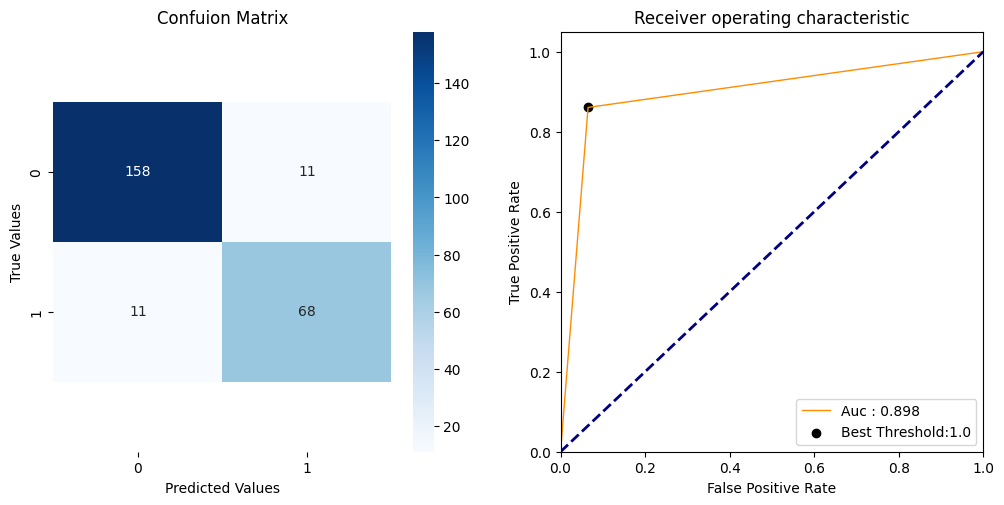

In [113]:
y_pred_FD4 = (model_FD4.predict(X_test_FD4) > 0.5).astype("int32")
print("\n=== FD004 Results ===")
print_results(fd4_y_true.failure, y_pred_FD4)

### Average of all results

In [114]:
def calculate_average_metrics(results_dict):
    """
    Calculate average metrics across all datasets.

    Parameters:
    -----------
    results_dict : dict
        Dictionary where keys are dataset names (e.g., 'FD001', 'FD002')
        and values are tuples of (y_true, y_pred)

    Returns:
    --------
    DataFrame with individual and average metrics
    """
    metrics_list = []

    for dataset_name, (y_true, y_pred) in results_dict.items():
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        metrics_list.append({
            'Dataset': dataset_name,
            'Accuracy': acc,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_list)

    # Calculate averages
    avg_metrics = {
        'Dataset': 'Average',
        'Accuracy': df_metrics['Accuracy'].mean(),
        'Precision': df_metrics['Precision'].mean(),
        'Recall': df_metrics['Recall'].mean(),
        'F1-Score': df_metrics['F1-Score'].mean()
    }

    # Append average row
    df_metrics = pd.concat([df_metrics, pd.DataFrame([avg_metrics])], ignore_index=True)

    return df_metrics


In [115]:
results = {
    'FD001': (fd1_y_true.failure, y_pred.flatten()),
    'FD002': (fd2_y_true.failure, y_pred_FD2.flatten()),
    'FD003': (fd3_y_true.failure, y_pred_FD3.flatten()),
    'FD004': (fd4_y_true.failure, y_pred_FD4.flatten())
}

# Calculate and display metrics
metrics_summary = calculate_average_metrics(results)
print(metrics_summary)

# Display with formatting
print("\n" + "="*70)
print("SUMMARY OF ALL DATASETS")
print("="*70)
print(metrics_summary.to_string(index=False))
print("="*70)

   Dataset  Accuracy  Precision    Recall  F1-Score
0    FD001  0.970000   0.909091  1.000000  0.952381
1    FD002  0.895753   0.800000  0.919540  0.855615
2    FD003  0.920000   0.783784  1.000000  0.878788
3    FD004  0.911290   0.860759  0.860759  0.860759
4  Average  0.924261   0.838409  0.945075  0.886886

SUMMARY OF ALL DATASETS
Dataset  Accuracy  Precision   Recall  F1-Score
  FD001  0.970000   0.909091 1.000000  0.952381
  FD002  0.895753   0.800000 0.919540  0.855615
  FD003  0.920000   0.783784 1.000000  0.878788
  FD004  0.911290   0.860759 0.860759  0.860759
Average  0.924261   0.838409 0.945075  0.886886
